# Behavioral Segmentation for Targeted Marketing
## Phase 1 — Data Loading & Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("retail_finding_dataa.csv")

In [3]:
df.sample(5)

,Customer_ID,Age,Gender,Region,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count,Preferred_Category
604,CUST0605,58,Female,East,421.88,2,45.8,1,Beauty
338,CUST0339,32,Female,West,146.46,1,57.3,1,Sports
413,CUST0414,36,Non-Binary,South,1154.32,9,42.2,0,Groceries
432,CUST0433,47,Female,North,653.73,2,61.0,1,Fashion
51,CUST0052,34,Non-Binary,North,1689.09,5,68.7,0,Books


In [4]:
df.head()

,Customer_ID,Age,Gender,Region,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count,Preferred_Category
0,CUST0001,27,Male,North,855.00,6,52.9,0,Health
1,CUST0002,47,Non-Binary,West,10791.93,21,24.5,4,Books
2,CUST0003,47,Female,North,7345.63,12,13.3,0,Beauty
3,CUST0004,55,Female,Central,18169.93,36,18.8,1,Books
4,CUST0005,54,Male,South,570.49,2,9.5,0,Sports


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   object 
 1   Age                 1000 non-null   int64  
 2   Gender              1000 non-null   object 
 3   Region              1000 non-null   object 
 4   Annual_Spending     1000 non-null   float64
 5   Purchase_Frequency  1000 non-null   int64  
 6   Discount_Usage_Pct  1000 non-null   float64
 7   Returns_Count       1000 non-null   int64  
 8   Preferred_Category  1000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.shape

(1000, 9)

In [7]:
df.size

9000

In [8]:
df.describe()

,Age,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,38.207000,4567.573800,12.528000,29.126500,1.249000
std,10.434128,4908.758211,12.276316,17.061921,1.641247
min,18.000000,50.790000,1.000000,5.000000,0.000000
25%,30.000000,762.382500,3.000000,15.700000,0.000000
50%,38.000000,2659.555000,9.000000,25.600000,1.000000
75%,45.000000,6733.765000,17.000000,38.275000,2.000000
max,70.000000,19907.090000,52.000000,70.000000,10.000000


In [9]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Region,0
Annual_Spending,0
Purchase_Frequency,0
Discount_Usage_Pct,0
Returns_Count,0
Preferred_Category,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.select_dtypes(include='object').columns:
    print(col, ':', df[col].unique())

Customer_ID : ['CUST0001' 'CUST0002' 'CUST0003' 'CUST0004' 'CUST0005' 'CUST0006'
 'CUST0007' 'CUST0008' 'CUST0009' 'CUST0010' 'CUST0011' 'CUST0012'
 'CUST0013' 'CUST0014' 'CUST0015' 'CUST0016' 'CUST0017' 'CUST0018'
 'CUST0019' 'CUST0020' 'CUST0021' 'CUST0022' 'CUST0023' 'CUST0024'
 'CUST0025' 'CUST0026' 'CUST0027' 'CUST0028' 'CUST0029' 'CUST0030'
 'CUST0031' 'CUST0032' 'CUST0033' 'CUST0034' 'CUST0035' 'CUST0036'
 'CUST0037' 'CUST0038' 'CUST0039' 'CUST0040' 'CUST0041' 'CUST0042'
 'CUST0043' 'CUST0044' 'CUST0045' 'CUST0046' 'CUST0047' 'CUST0048'
 'CUST0049' 'CUST0050' 'CUST0051' 'CUST0052' 'CUST0053' 'CUST0054'
 'CUST0055' 'CUST0056' 'CUST0057' 'CUST0058' 'CUST0059' 'CUST0060'
 'CUST0061' 'CUST0062' 'CUST0063' 'CUST0064' 'CUST0065' 'CUST0066'
 'CUST0067' 'CUST0068' 'CUST0069' 'CUST0070' 'CUST0071' 'CUST0072'
 'CUST0073' 'CUST0074' 'CUST0075' 'CUST0076' 'CUST0077' 'CUST0078'
 'CUST0079' 'CUST0080' 'CUST0081' 'CUST0082' 'CUST0083' 'CUST0084'
 'CUST0085' 'CUST0086' 'CUST0087' 'CUST0088' 'CU

### Observations from Initial Exploration:
1. The dataset has **1000 rows and 9 columns** — a clean, well-structured retail dataset.
2. There are **no missing values** and **no duplicate records**, so no data cleaning is required.
3. The key features for clustering are `Annual_Spending` and `Purchase_Frequency`, as specified.
4. Categorical columns: `Gender` (3 categories), `Region` (5 categories), `Preferred_Category` (10 categories).
5. `Customer_ID` is an identifier column and will be excluded from analysis.

In [12]:
for c in ['Gender', 'Region', 'Preferred_Category']:
    print(f"\n--- {c} ---")
    print(df[c].value_counts())


--- Gender ---
Gender
Non-Binary    367
Male          320
Female        313
Name: count, dtype: int64

--- Region ---
Region
North      225
West       203
South      198
Central    195
East       179
Name: count, dtype: int64

--- Preferred_Category ---
Preferred_Category
Books            115
Travel           114
Beauty           106
Fashion          104
Groceries        102
Health            95
Dining            93
Electronics       93
Sports            89
Home & Living     89
Name: count, dtype: int64


In [13]:
nc = ['Age', 'Annual_Spending', 'Purchase_Frequency', 'Discount_Usage_Pct', 'Returns_Count']
df[nc].skew()

,0
Age,0.383967
Annual_Spending,1.410179
Purchase_Frequency,1.555263
Discount_Usage_Pct,0.727411
Returns_Count,2.358881


### Observations from Skewness:
1. `Annual_Spending` (skew ≈ 1.41) and `Purchase_Frequency` (skew ≈ 1.56) are both **right-skewed**, meaning a few high-spending, high-frequency customers pull the distribution.
2. `Age` and `Discount_Usage_Pct` are approximately symmetric.
3. Right-skewed features justify the use of StandardScaler in Phase 2 to normalize before clustering.

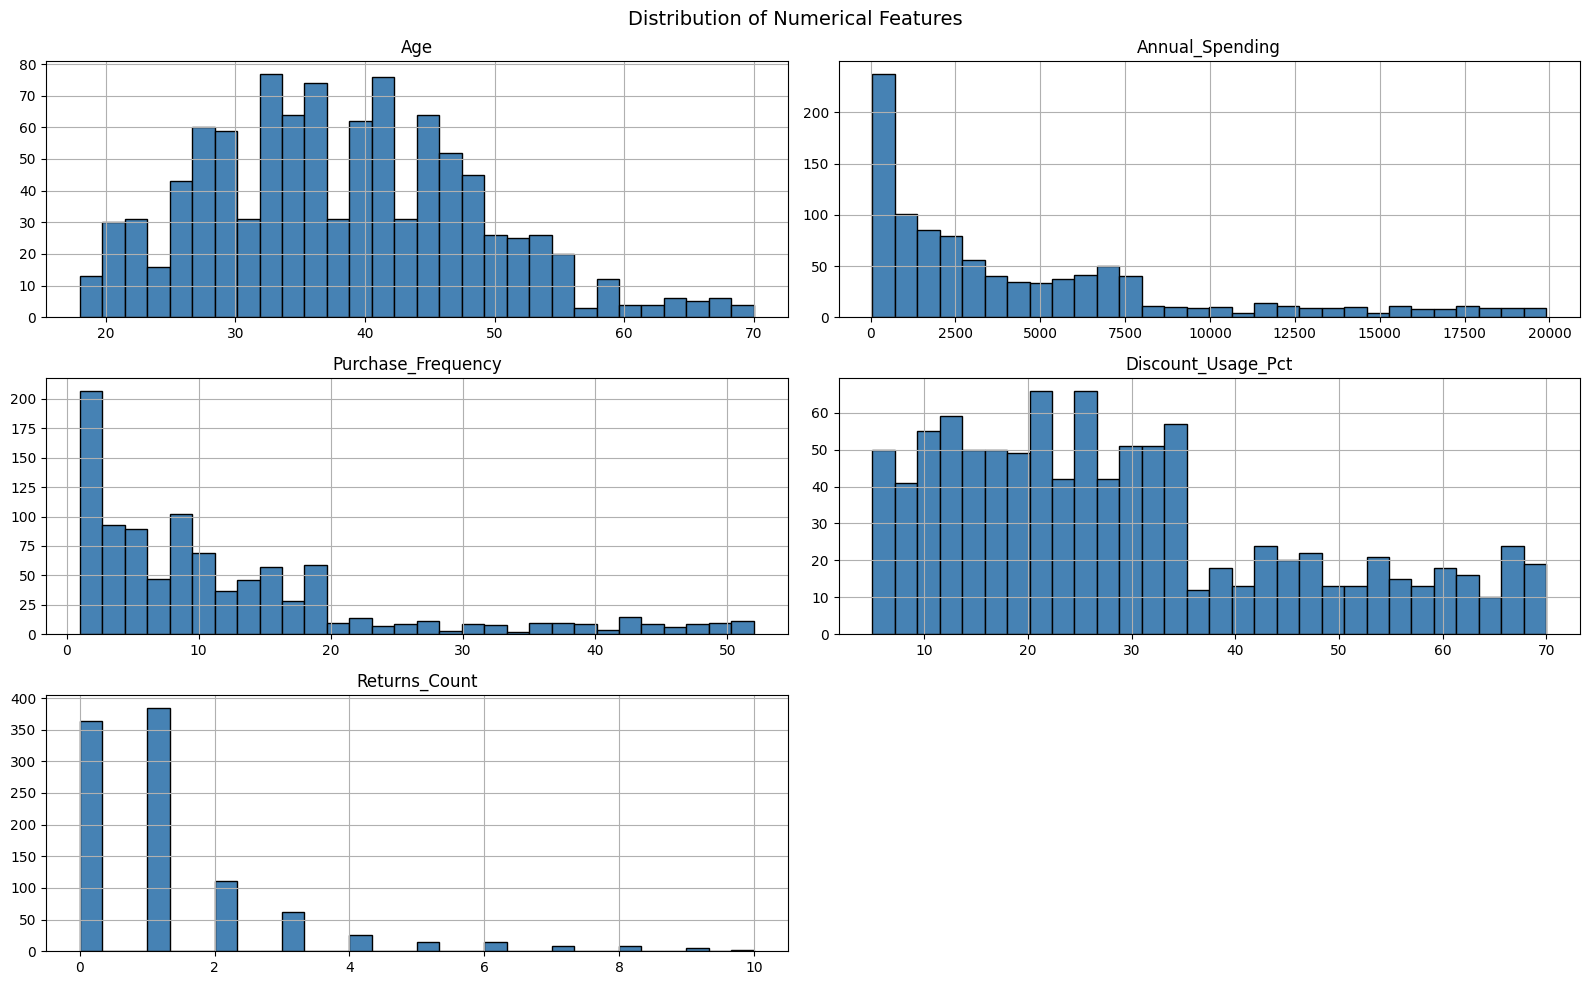

In [14]:
df[nc].hist(figsize=(16, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

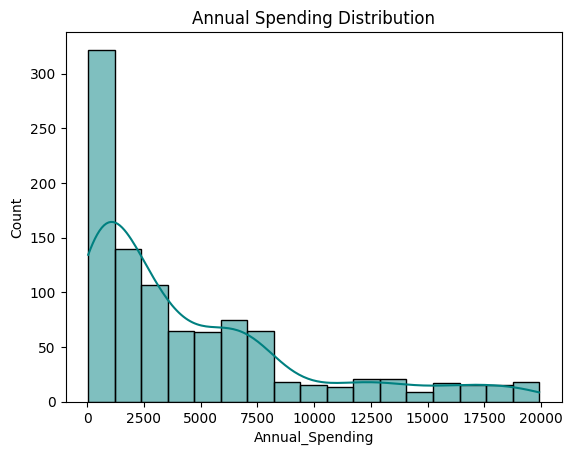

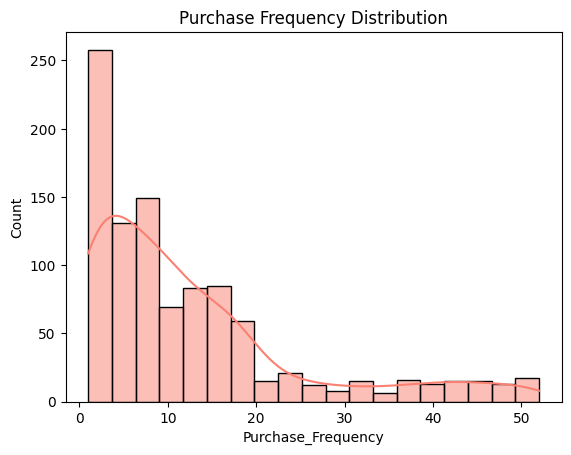

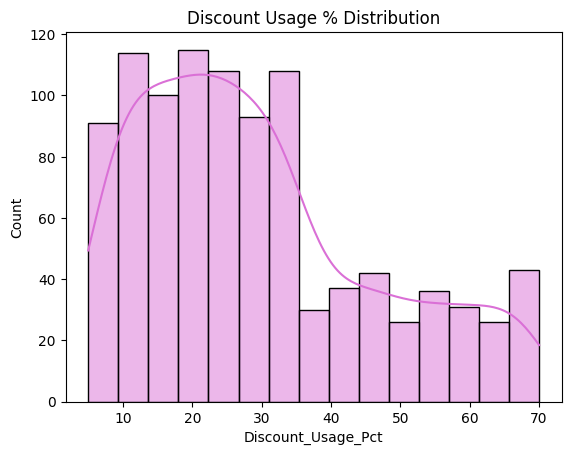

In [15]:
sns.histplot(df['Annual_Spending'], kde=True, color='teal')
plt.title('Annual Spending Distribution')
plt.show()

sns.histplot(df['Purchase_Frequency'], kde=True, color='salmon')
plt.title('Purchase Frequency Distribution')
plt.show()

sns.histplot(df['Discount_Usage_Pct'], kde=True, color='orchid')
plt.title('Discount Usage % Distribution')
plt.show()

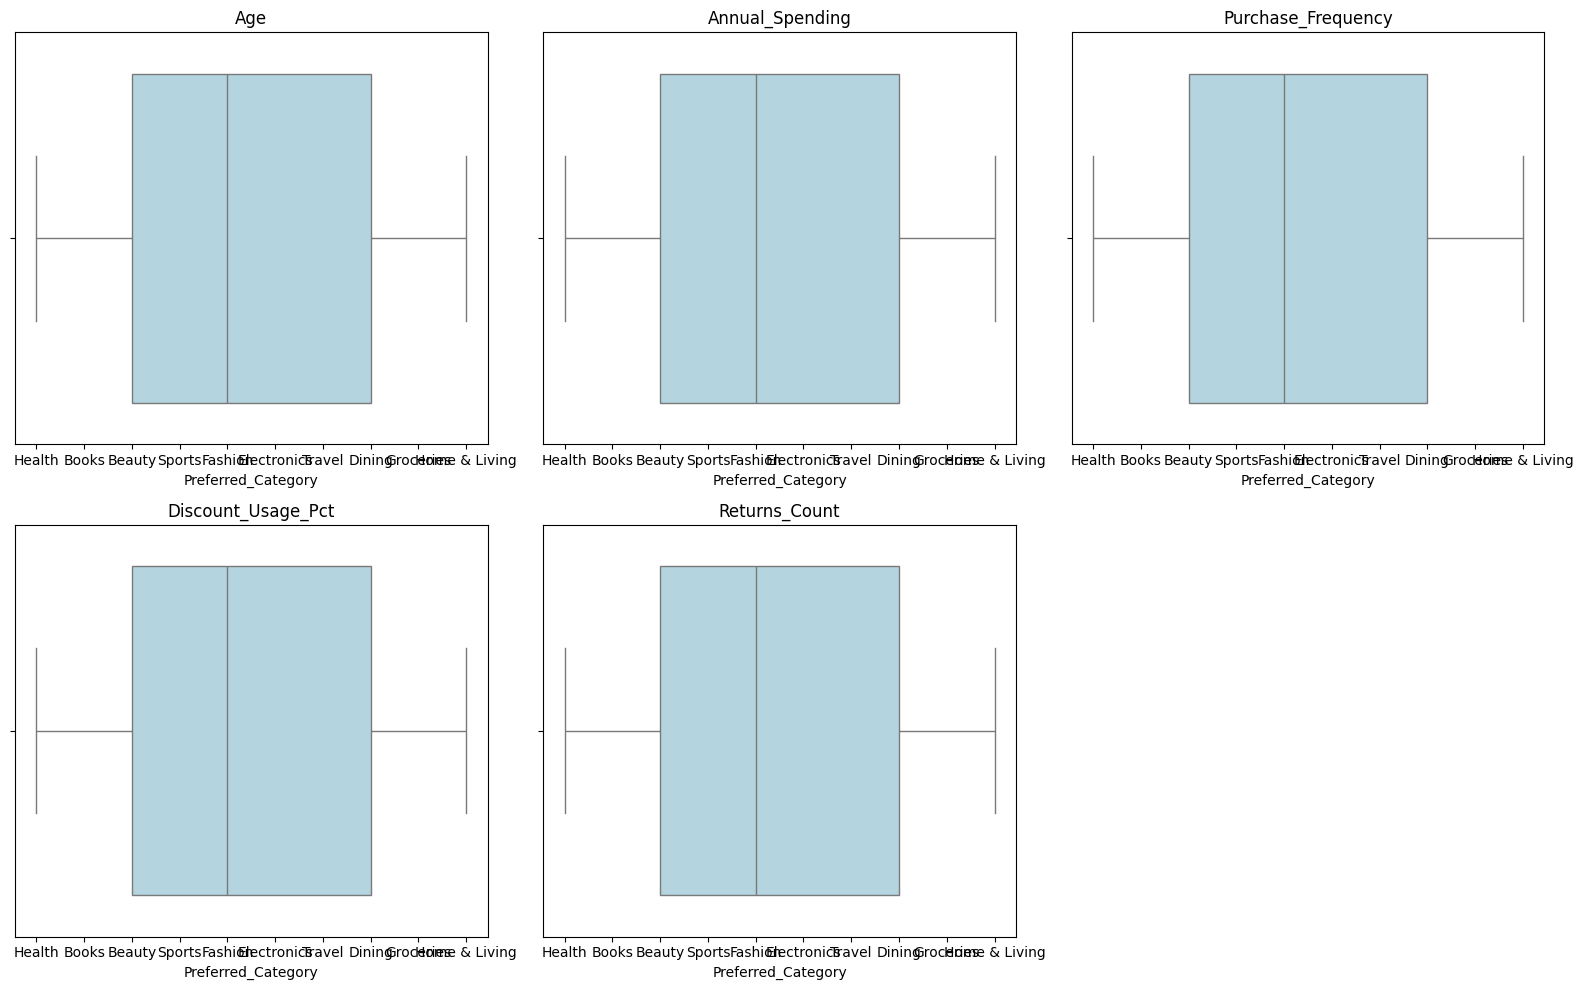

In [16]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(nc, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[c], color='lightblue')
    plt.title(col)

plt.tight_layout()
plt.show()

### Observations from Boxplots:
1. `Annual_Spending` has a wide spread with visible outliers — some customers are extreme high spenders.
2. `Purchase_Frequency` also shows outliers on the upper end, consistent with its right skew.
3. `Returns_Count` is mostly 0–2, but a few customers have high return counts.
4. Outliers in `Annual_Spending` and `Purchase_Frequency` represent real customer behavior (e.g., premium buyers) and should **not** be removed — they help define meaningful personas.

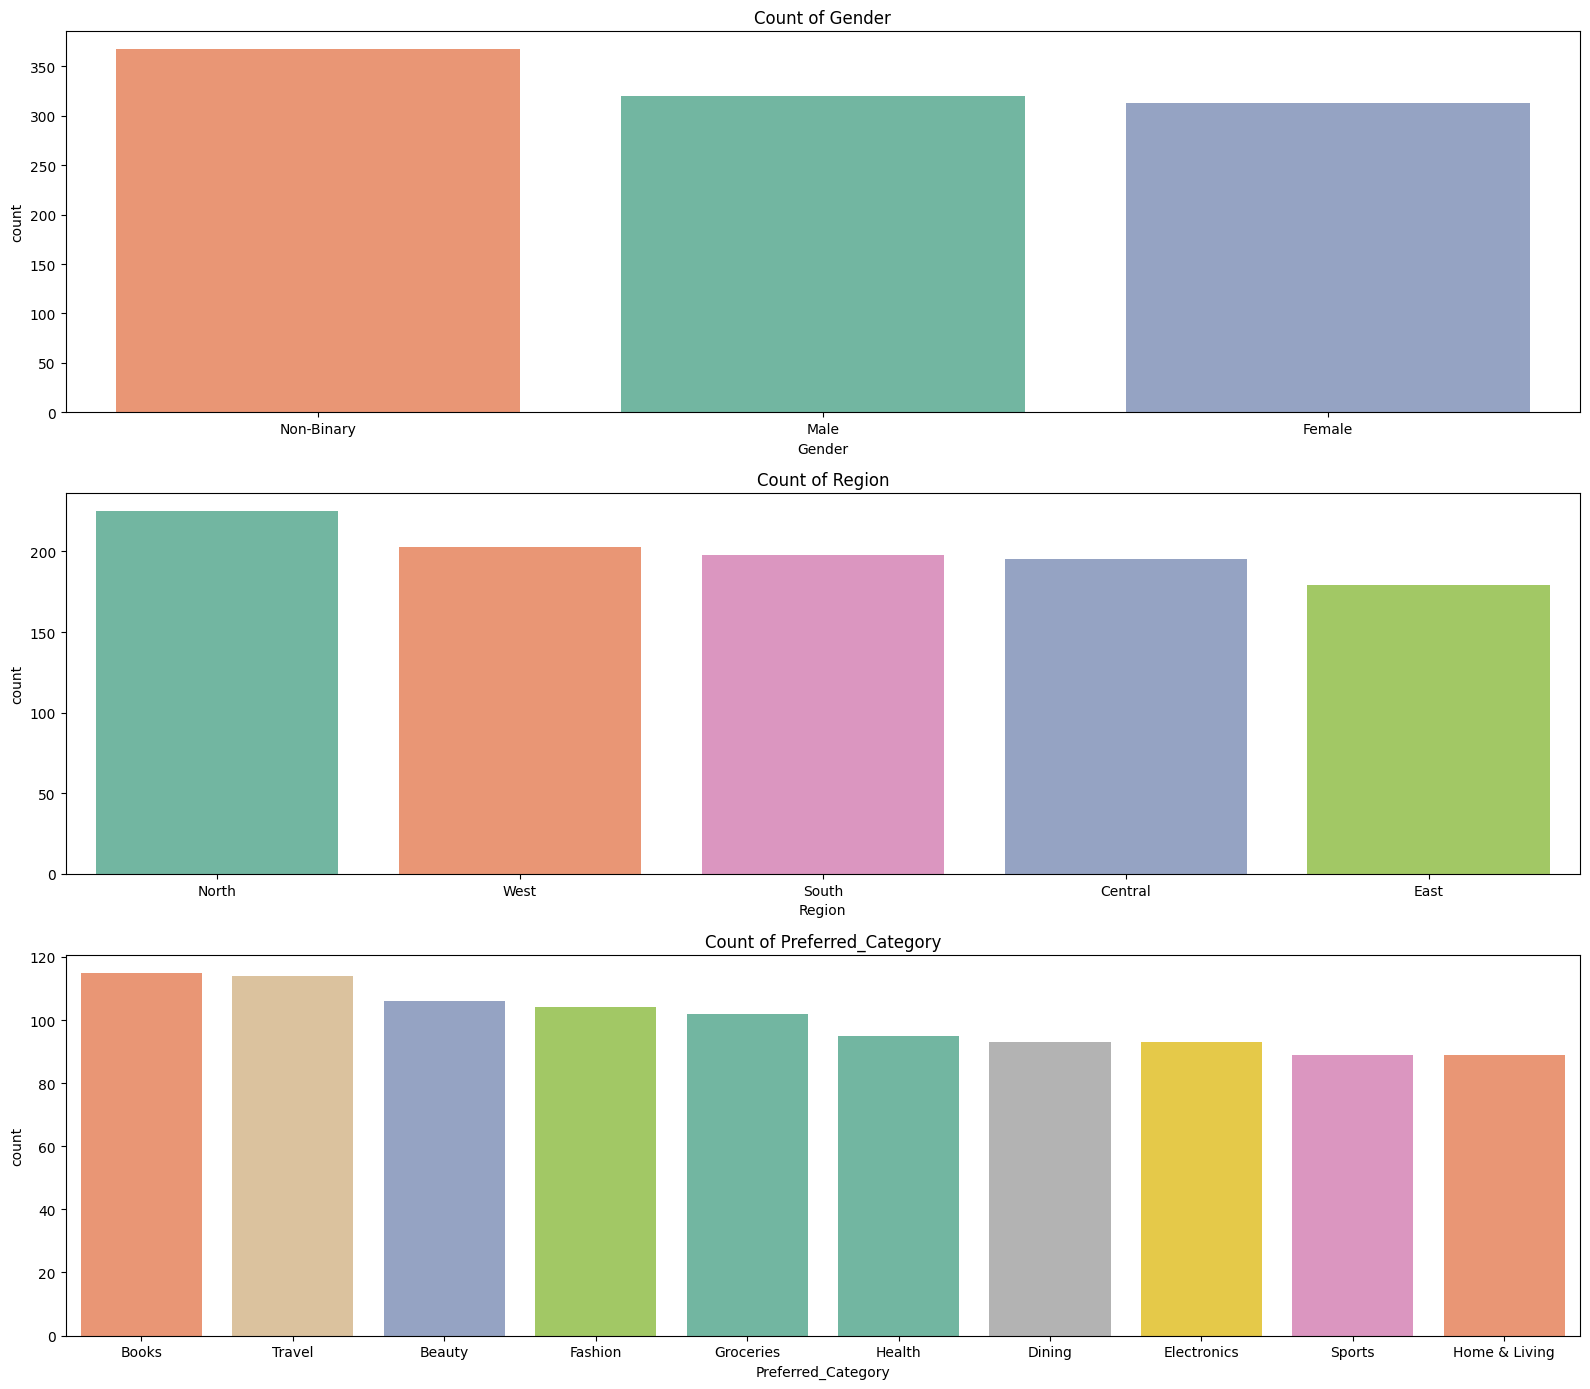

In [17]:
cat_cols = ['Gender', 'Region', 'Preferred_Category']

plt.figure(figsize=(16, 14))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2', hue=col, legend=False)
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

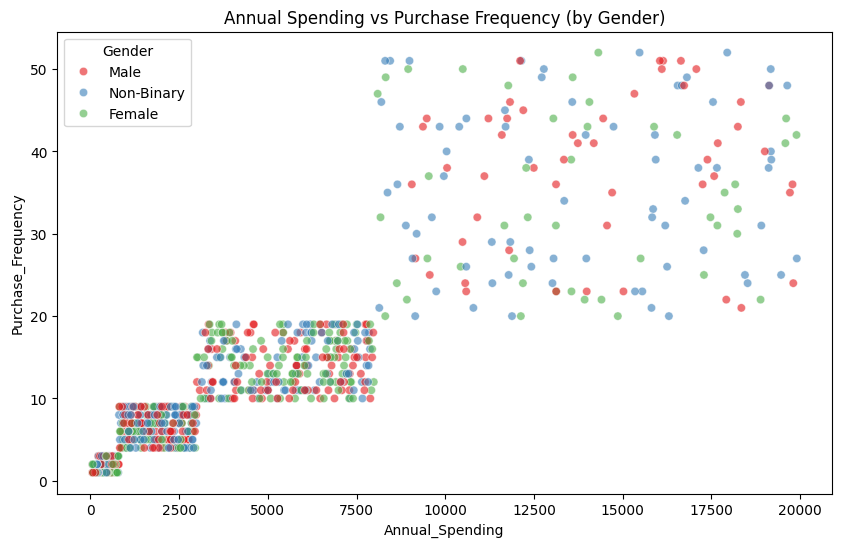

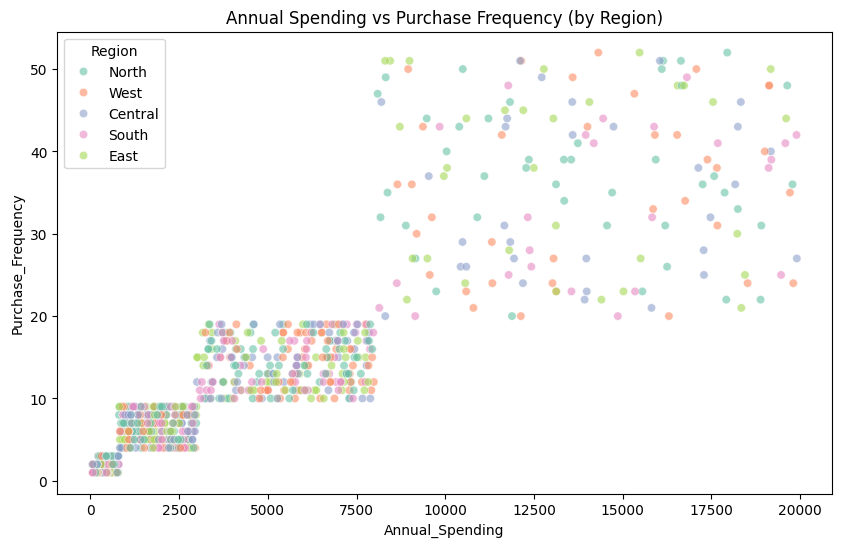

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Spending', y='Purchase_Frequency',
                hue='Gender', palette='Set1', alpha=0.6)
plt.title('Annual Spending vs Purchase Frequency (by Gender)')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Spending', y='Purchase_Frequency',
                hue='Region', palette='Set2', alpha=0.6)
plt.title('Annual Spending vs Purchase Frequency (by Region)')
plt.show()

In [19]:
df.groupby('Preferred_Category')[['Annual_Spending', 'Purchase_Frequency']].mean().sort_values(
    by='Annual_Spending', ascending=False)

,Annual_Spending,Purchase_Frequency
Preferred_Category,,
Books,5450.961304,14.321739
Fashion,5147.035192,13.605769
Groceries,4723.996961,13.117647
Dining,4678.315806,13.322581
Electronics,4615.337527,13.129032
Travel,4486.591316,12.570175
Health,4466.858947,12.052632
Home & Living,4125.976517,12.022472
Beauty,4103.393962,11.018868


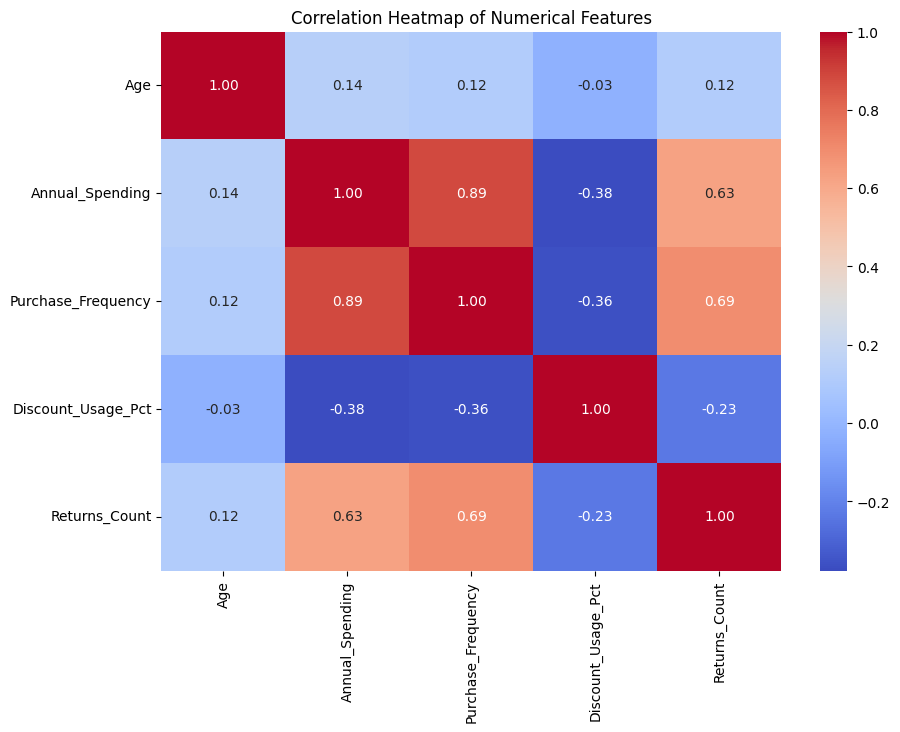

In [20]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[nc].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Observations from Correlation Heatmap:
1. `Annual_Spending` and `Purchase_Frequency` are **strongly positively correlated (0.89)** — customers who buy more frequently also tend to spend more annually. This makes them ideal clustering features.
2. `Returns_Count` is also positively correlated with `Annual_Spending` (0.63) — higher-spending customers tend to return more items.
3. `Discount_Usage_Pct` is **negatively correlated** with `Annual_Spending` (-0.38), suggesting price-sensitive customers spend less overall.
4. `Age` has weak correlations with all features, indicating age alone does not predict spending behavior.

### Phase 1 — Summary of EDA Findings:
1. The dataset is clean with no missing values or duplicates — ready for modeling.
2. `Annual_Spending` and `Purchase_Frequency` are right-skewed and require scaling before clustering.
3. Their strong mutual correlation (0.89) confirms they capture the same behavioral dimension: **purchasing power**.
4. The dataset shows diverse customer segments across gender, region, and category preferences.
5. The Elbow Method in Phase 2 will determine the optimal number of customer persona clusters.

---

## Phase 2 — Preprocessing, K-Means Clustering & Elbow Method

**Pipeline:** StandardScaler → K-Means → Elbow Method Visualization → Persona Identification

In [21]:

features = ['Annual_Spending', 'Purchase_Frequency']
X = df[features].copy()
X.head()

,Annual_Spending,Purchase_Frequency
0,855.00,6
1,10791.93,21
2,7345.63,12
3,18169.93,36
4,570.49,2


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data (first 5 rows):")
print(X.head().to_string())
print("\nScaled data (first 5 rows):")
print(X_scaled[:5])

Original data (first 5 rows):
   Annual_Spending  Purchase_Frequency
0           855.00                   6
1         10791.93                  21
2          7345.63                  12
3         18169.93                  36
4           570.49                   2

Scaled data (first 5 rows):
[[-0.75669473 -0.53202171]
 [ 1.26864483  0.69045465]
 [ 0.56622187 -0.04303117]
 [ 2.77242469  1.91293102]
 [-0.8146834  -0.85801541]]


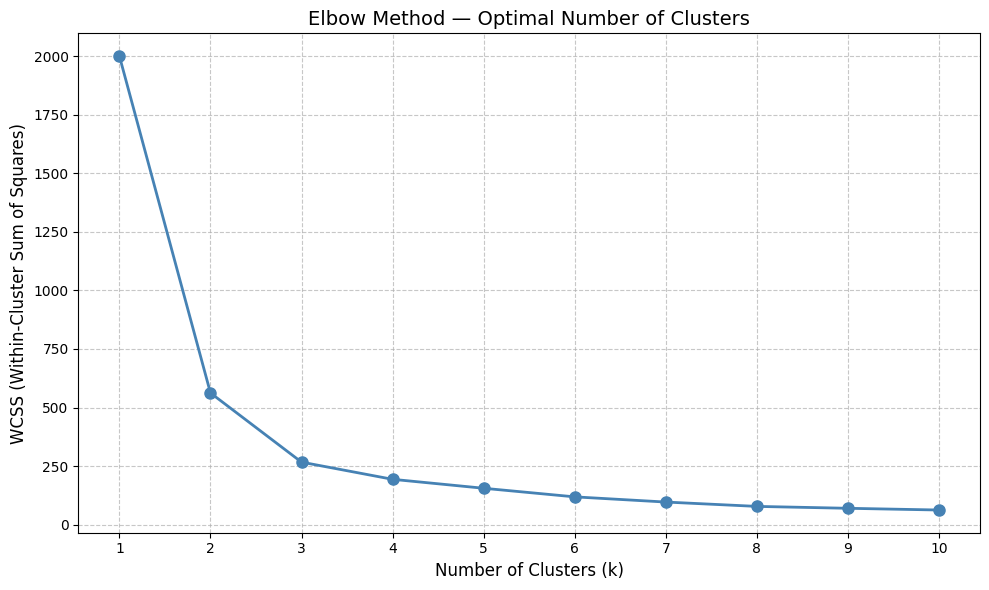

In [23]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Elbow Method Visualization
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Elbow Method Observation:
- The WCSS (inertia) drops sharply from k=1 to k=4, then begins to level off.
- The **elbow** is visually identifiable at **k=4**, where the rate of decrease slows significantly.
- Choosing k=4 balances model simplicity with meaningful customer segmentation — giving us 4 distinct customer personas.

In [24]:
# Fit K-Means with optimal k=4
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(X_scaled)

df['Cluster'] = kmeans_final.labels_

print("Cluster label counts:")
print(df['Cluster'].value_counts().sort_index())

Cluster label counts:
Cluster
0     75
1    539
2    300
3     86
Name: count, dtype: int64


In [25]:
from sklearn.metrics import silhouette_score

In [26]:
sil_score = silhouette_score(X_scaled, kmeans_final.labels_)

print(f"Silhouette Score for K-Means (k=4): {sil_score:.4f}")

Silhouette Score for K-Means (k=4): 0.6091


In [27]:
if sil_score > 0.5:
    print("Interpretation: Good clustering. Personas are well separated.")
elif sil_score > 0.2:
    print("Interpretation: Fair clustering. Some personas overlap slightly.")
else:
    print("Interpretation: Poor clustering. Personas overlap heavily.")

Interpretation: Good clustering. Personas are well separated.


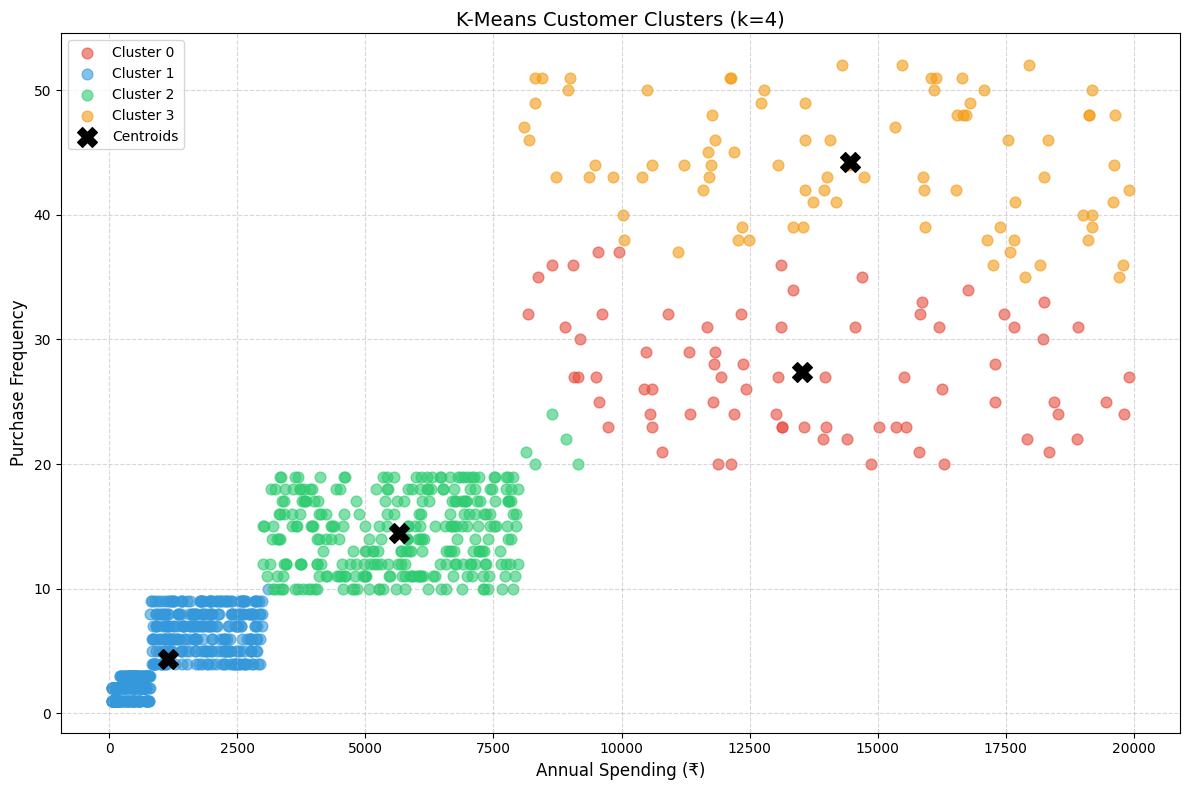

In [28]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
persona_names = {0: 'Persona 0', 1: 'Persona 1', 2: 'Persona 2', 3: 'Persona 3'}

plt.figure(figsize=(12, 8))
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual_Spending'],
                cluster_data['Purchase_Frequency'],
                c=colors[cluster_id],
                label=f'Cluster {cluster_id}',
                alpha=0.6,
                s=60)

centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.title('K-Means Customer Clusters (k=4)', fontsize=14)
plt.xlabel('Annual Spending (₹)', fontsize=12)
plt.ylabel('Purchase Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
# Analyze cluster profiles
cluster_profile = df.groupby('Cluster')[['Annual_Spending', 'Purchase_Frequency',
                                          'Discount_Usage_Pct', 'Returns_Count', 'Age']].mean().round(2)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Annual_Spending,Purchase_Frequency,Discount_Usage_Pct,Returns_Count,Age,Count
Cluster,,,,,,
0,13527.00,27.37,20.31,2.73,43.52,75
1,1141.89,4.34,36.70,0.53,37.16,539
2,5648.92,14.45,20.46,1.29,37.67,300
3,14452.23,44.20,19.60,4.35,42.01,86


In [30]:
# Assign persona names
persona_map = {
    0: 'Budget Buyers',
    1: 'Occasional Shoppers',
    2: 'Regular Spenders',
    3: 'Premium High-Value Customers'
}

df['Persona'] = df['Cluster'].map(persona_map)

print("Persona Distribution:")
print(df['Persona'].value_counts())

Persona Distribution:
Persona
Occasional Shoppers             539
Regular Spenders                300
Premium High-Value Customers     86
Budget Buyers                    75
Name: count, dtype: int64


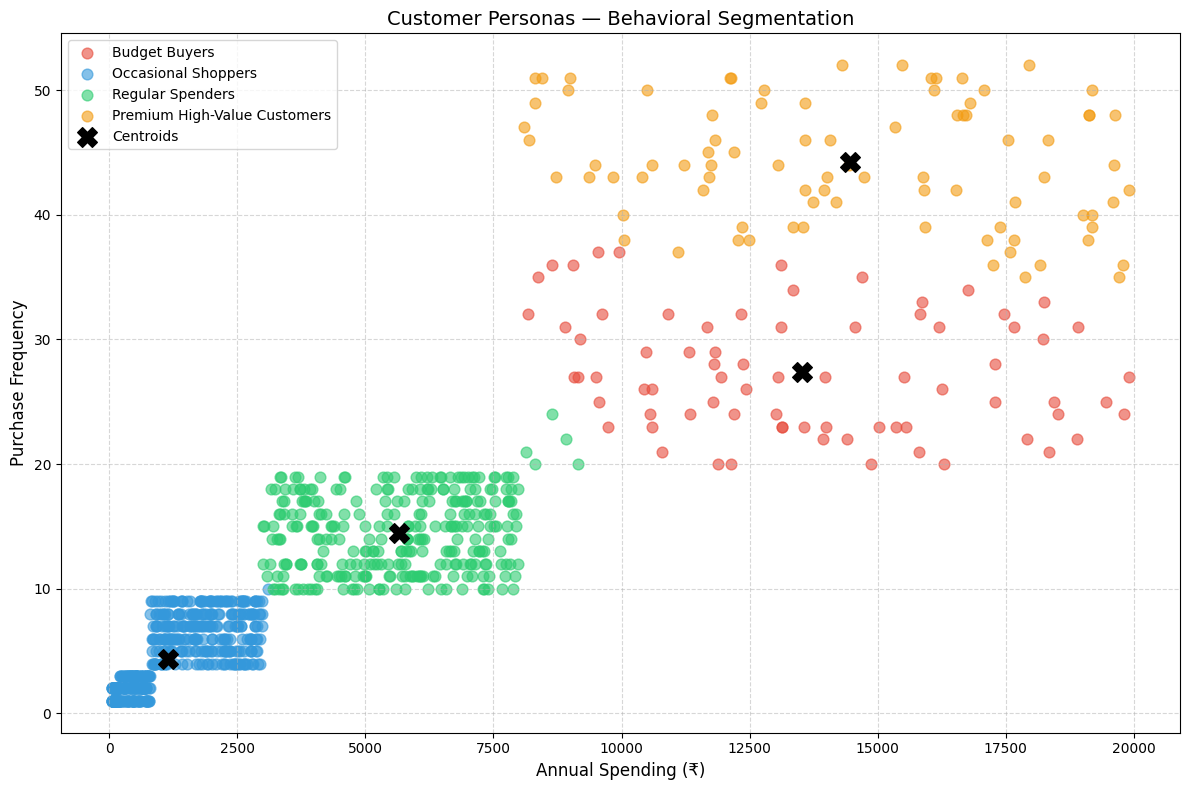

In [31]:
persona_colors = {
    'Budget Buyers':                 '#E74C3C',
    'Occasional Shoppers':           '#3498DB',
    'Regular Spenders':              '#2ECC71',
    'Premium High-Value Customers':  '#F39C12'
}

plt.figure(figsize=(12, 8))
for persona, color in persona_colors.items():
    group = df[df['Persona'] == persona]
    plt.scatter(group['Annual_Spending'], group['Purchase_Frequency'],
                c=color, label=persona, alpha=0.6, s=60)

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.title('Customer Personas — Behavioral Segmentation', fontsize=14)
plt.xlabel('Annual Spending (₹)', fontsize=12)
plt.ylabel('Purchase Frequency', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

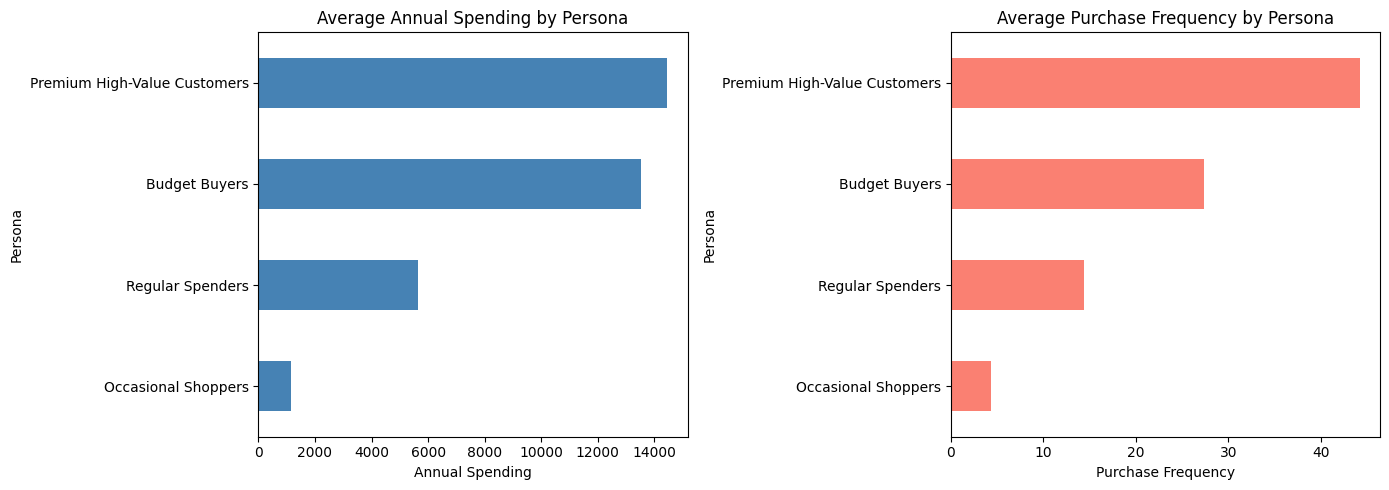

In [32]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
persona_spending = df.groupby('Persona')['Annual_Spending'].mean().sort_values()
persona_spending.plot(kind='barh', color='steelblue')
plt.title('Average Annual Spending by Persona')
plt.xlabel('Annual Spending')

plt.subplot(1, 2, 2)
persona_freq = df.groupby('Persona')['Purchase_Frequency'].mean().sort_values()
persona_freq.plot(kind='barh', color='salmon')
plt.title('Average Purchase Frequency by Persona')
plt.xlabel('Purchase Frequency')

plt.tight_layout()
plt.show()

In [33]:
persona_summary = df.groupby('Persona').agg(
    Count=('Customer_ID', 'count'),
    Avg_Annual_Spending=('Annual_Spending', 'mean'),
    Avg_Purchase_Frequency=('Purchase_Frequency', 'mean'),
    Avg_Discount_Usage=('Discount_Usage_Pct', 'mean'),
    Avg_Returns=('Returns_Count', 'mean'),
    Avg_Age=('Age', 'mean')
).round(2)

persona_summary

,Count,Avg_Annual_Spending,Avg_Purchase_Frequency,Avg_Discount_Usage,Avg_Returns,Avg_Age
Persona,,,,,,
Budget Buyers,75,13527.00,27.37,20.31,2.73,43.52
Occasional Shoppers,539,1141.89,4.34,36.70,0.53,37.16
Premium High-Value Customers,86,14452.23,44.20,19.60,4.35,42.01
Regular Spenders,300,5648.92,14.45,20.46,1.29,37.67


In [34]:
# --- Age Group Binning ---
bins = [0, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print("Age Group Distribution:")
print(df['Age_Group'].value_counts().sort_index())

Age Group Distribution:
Age_Group
18-25    108
26-35    316
36-45    338
46-55    183
56+       55
Name: count, dtype: int64


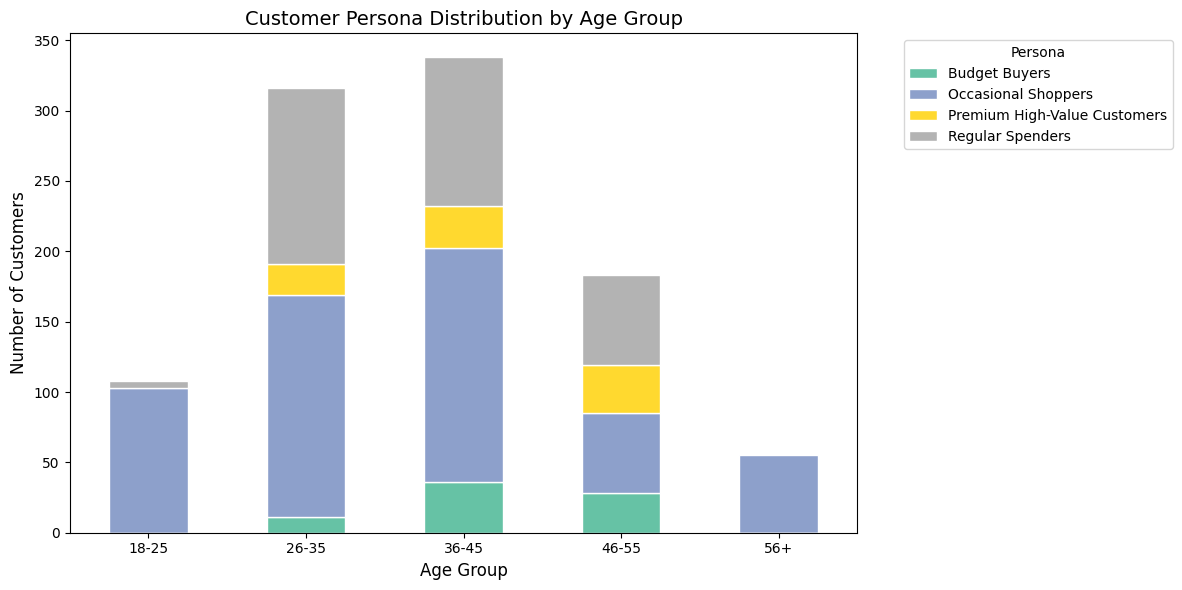

In [35]:
# --- Persona Distribution across Age Groups ---
age_persona = df.groupby(['Age_Group', 'Persona'], observed=True).size().unstack(fill_value=0)

age_persona.plot(kind='bar', stacked=True, figsize=(12, 6),
                  colormap='Set2', edgecolor='white')
plt.title('Customer Persona Distribution by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

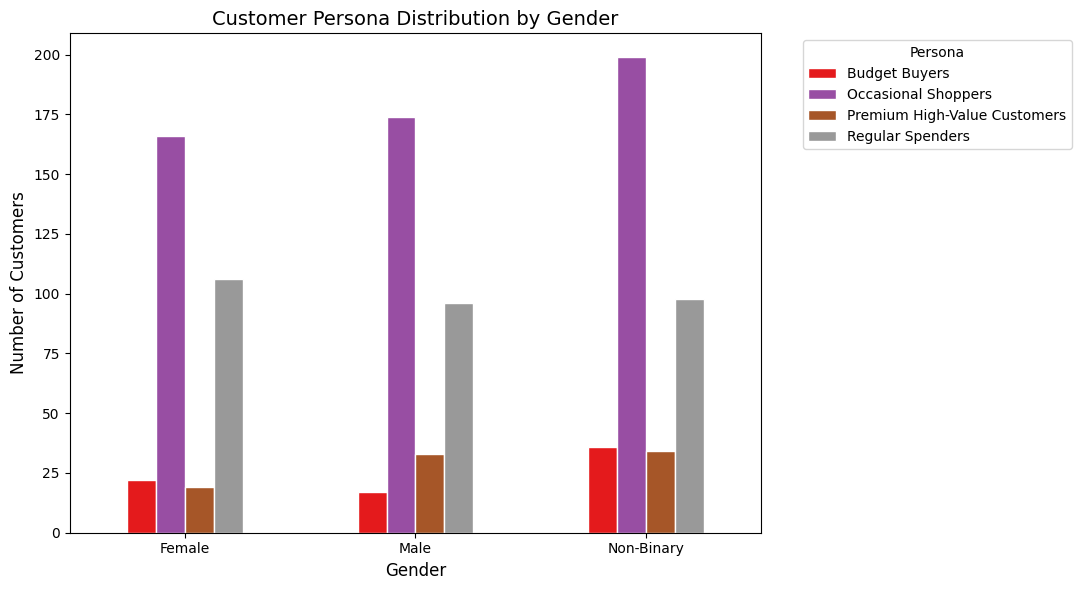

In [36]:
# --- Persona Distribution across Gender ---
gender_persona = df.groupby(['Gender', 'Persona']).size().unstack(fill_value=0)

gender_persona.plot(kind='bar', figsize=(11, 6),
                     colormap='Set1', edgecolor='white')
plt.title('Customer Persona Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

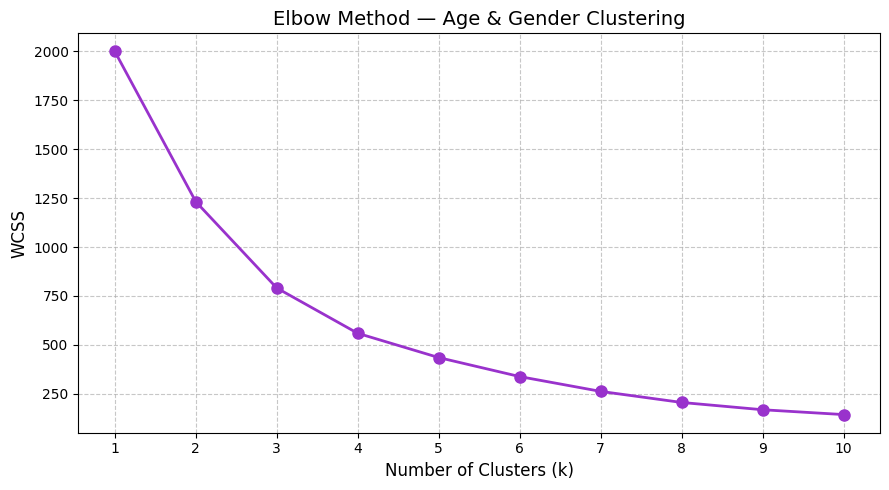

In [37]:
# --- K-Means Clustering on Age ---
# Encode Gender numerically for clustering
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

# Features: Age + Gender (encoded)
X_ag = df[['Age', 'Gender_Encoded']].copy()

scaler_ag = StandardScaler()
X_ag_scaled = scaler_ag.fit_transform(X_ag)

# Elbow Method for Age-Gender clustering
wcss_ag = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_ag_scaled)
    wcss_ag.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss_ag, marker='o', color='darkorchid', linewidth=2, markersize=8)
plt.title('Elbow Method — Age & Gender Clustering', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
# --- Fit K-Means on Age + Gender (k=3, adjust if elbow differs) ---
optimal_k_ag = 3

km_ag = KMeans(n_clusters=optimal_k_ag, init='k-means++', n_init=10, random_state=42)
km_ag.fit(X_ag_scaled)

df['Age_Gender_Cluster'] = km_ag.labels_

# Silhouette score
sil_ag = silhouette_score(X_ag_scaled, km_ag.labels_)
print(f"Silhouette Score (Age + Gender Clustering, k={optimal_k_ag}): {sil_ag:.4f}")

print("\nCluster size distribution:")
print(df['Age_Gender_Cluster'].value_counts().sort_index())

Silhouette Score (Age + Gender Clustering, k=3): 0.4154

Cluster size distribution:
Age_Gender_Cluster
0    383
1    312
2    305
Name: count, dtype: int64


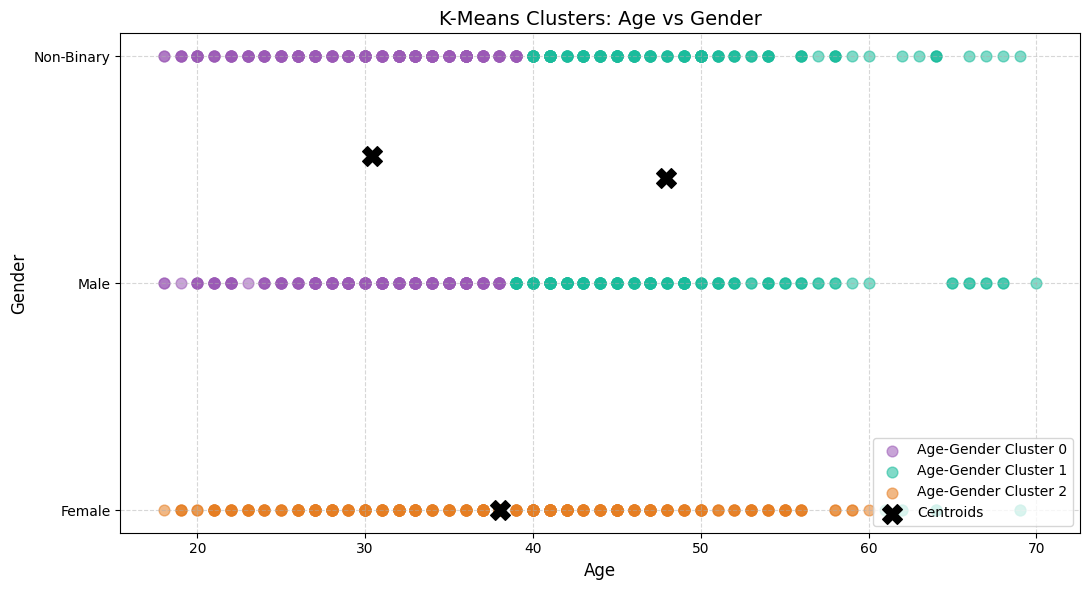

In [39]:
# --- Visualize Age-Gender Clusters ---
cluster_colors_ag = ['#9B59B6', '#1ABC9C', '#E67E22']

plt.figure(figsize=(11, 6))
for cid in range(optimal_k_ag):
    subset = df[df['Age_Gender_Cluster'] == cid]
    plt.scatter(subset['Age'], subset['Gender_Encoded'],
                c=cluster_colors_ag[cid], label=f'Age-Gender Cluster {cid}',
                alpha=0.55, s=60)

# Centroids in original space
centroids_ag = scaler_ag.inverse_transform(km_ag.cluster_centers_)
plt.scatter(centroids_ag[:, 0], centroids_ag[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.yticks([0, 1, 2], le.classes_)
plt.title('K-Means Clusters: Age vs Gender', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Gender', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
# --- Age-Gender Cluster Profile ---
ag_profile = df.groupby('Age_Gender_Cluster').agg(
    Count=('Customer_ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Spending=('Annual_Spending', 'mean'),
    Avg_Frequency=('Purchase_Frequency', 'mean'),
    Top_Gender=('Gender', lambda x: x.mode()[0])
).round(2)

print("Age-Gender Cluster Profiles:")
ag_profile

Age-Gender Cluster Profiles:


,Count,Avg_Age,Avg_Spending,Avg_Frequency,Top_Gender
Age_Gender_Cluster,,,,,
0,383,30.39,3766.40,11.17,Non-Binary
1,312,47.94,5657.95,14.74,Male
2,305,38.06,4458.24,11.97,Female


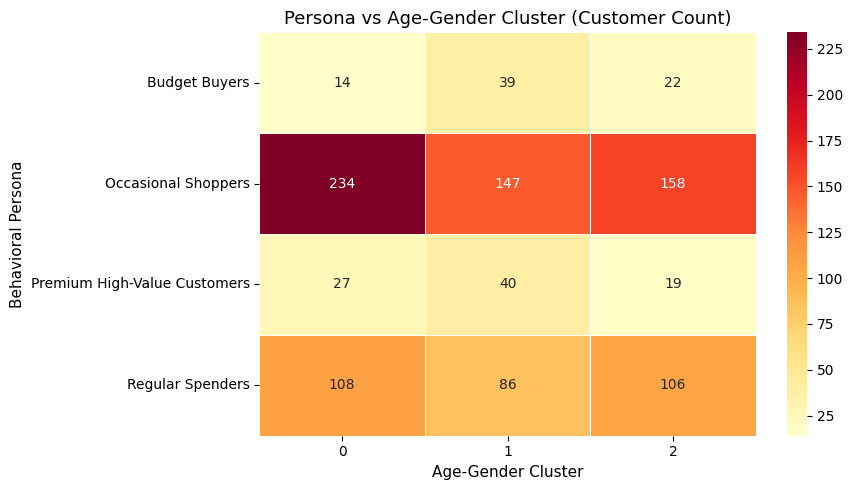

In [41]:
# --- Cross-Analysis: Behavioral Persona × Age-Gender Cluster ---
cross = pd.crosstab(df['Persona'], df['Age_Gender_Cluster'])

plt.figure(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Persona vs Age-Gender Cluster (Customer Count)', fontsize=13)
plt.xlabel('Age-Gender Cluster', fontsize=11)
plt.ylabel('Behavioral Persona', fontsize=11)
plt.tight_layout()
plt.show()

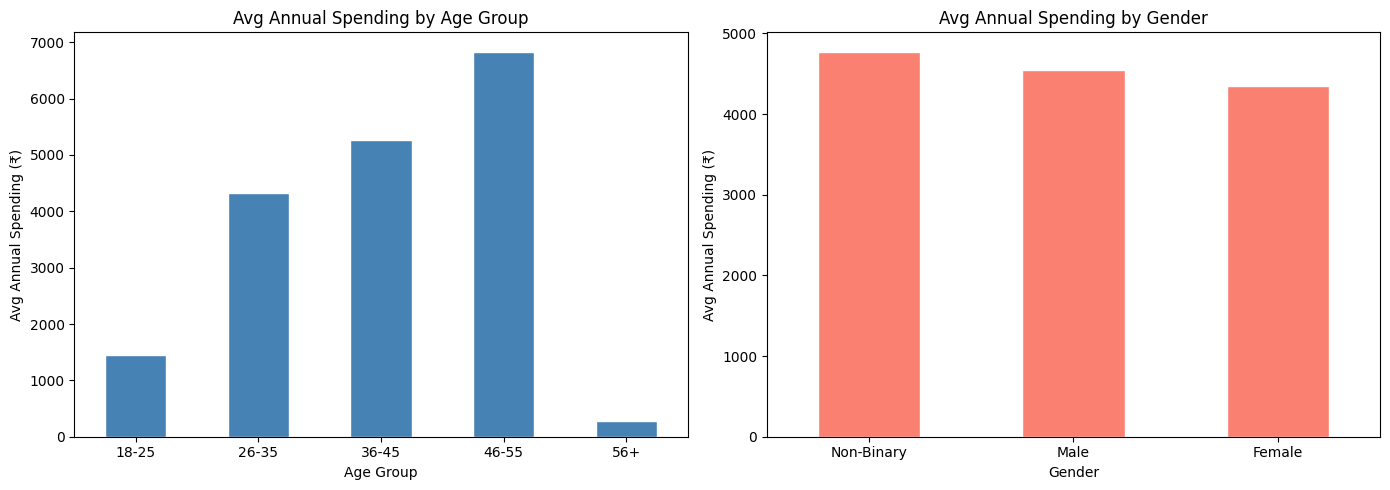

In [42]:
# --- Average Annual Spending by Age Group and Gender ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Age Group
age_spending = df.groupby('Age_Group', observed=True)['Annual_Spending'].mean().sort_index()
age_spending.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Annual Spending by Age Group', fontsize=12)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Avg Annual Spending (₹)')
axes[0].tick_params(axis='x', rotation=0)

# By Gender
gender_spending = df.groupby('Gender')['Annual_Spending'].mean().sort_values(ascending=False)
gender_spending.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Avg Annual Spending by Gender', fontsize=12)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Avg Annual Spending (₹)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Phase 2 — Final Observations & Marketing Recommendations:

| Persona | Behavior | Marketing Strategy |
|---|---|---|
| **Budget Buyers** | Low spending, low frequency | Offer discount coupons & flash sales |
| **Occasional Shoppers** | Moderate spending, infrequent | Re-engagement campaigns, loyalty points |
| **Regular Spenders** | Moderate-high spending, consistent | Subscription offers, early access deals |
| **Premium High-Value Customers** | High spending, high frequency | VIP programs, exclusive product launches |

#### Summary:
1. K-Means with `k=4` (chosen via the Elbow Method) successfully identifies **4 distinct customer personas**.
2. StandardScaler was essential — without it, `Annual_Spending`'s larger scale would have dominated clustering.
3. `Purchase_Frequency` and `Annual_Spending` together form a strong behavioral indicator of **purchasing power**.
4. These personas enable businesses to tailor marketing efforts, improving customer retention and ROI.

### Observations — Age & Gender Clustering:

1. **Age Groups and Personas** — The stacked bar chart reveals which age groups predominantly fall into each persona (e.g., younger customers may skew toward Budget Buyers, while older groups align with Premium Customers).
2. **Gender and Personas** — The grouped bar chart shows whether any gender category is over-represented in high-value personas, informing gender-targeted marketing.
3. **K-Means on Age + Gender** — With `k=3`, K-Means identifies natural demographic segments. The Silhouette Score validates separation quality.
4. **Cross-Analysis Heatmap** — Reveals how behavioral personas and demographic clusters overlap, enabling hyper-targeted campaigns (e.g., Premium Female customers in the 36–45 age band).
5. **Spending by Age & Gender** — The bar charts quantify which demographic groups drive the most revenue, directly guiding budget allocation for marketing campaigns.

### Combined Segmentation Insight:
> Combining **behavioral clustering** (Annual Spending + Purchase Frequency) with **demographic clustering** (Age + Gender) gives a 360° view of the customer — enabling both *what they do* and *who they are* to shape personalized marketing strategies.

In [43]:
assert 'df' in globals(), "DataFrame 'df' not found."
print("Data loaded with shape:", df.shape)

Data loaded with shape: (1000, 14)


In [44]:
FEATURE_POOL = [
    'Age',
    'Annual_Spending',
    'Purchase_Frequency',
    'Returns_Count',
    'Discount_Usage_Pct'
]

# Keep only columns that exist in df
FEATURE_POOL = [c for c in FEATURE_POOL if c in df.columns]
print("Usable features:", FEATURE_POOL)

Usable features: ['Age', 'Annual_Spending', 'Purchase_Frequency', 'Returns_Count', 'Discount_Usage_Pct']


In [45]:
feature_sets = [
    ['Annual_Spending', 'Purchase_Frequency'],
    ['Annual_Spending', 'Returns_Count'],
    ['Purchase_Frequency', 'Discount_Usage_Pct'],
    ['Age', 'Annual_Spending'],
    ['Age', 'Purchase_Frequency']
]

feature_sets = [fs for fs in feature_sets if all(f in FEATURE_POOL for f in fs)]
print("Feature pairs used:", feature_sets)

Feature pairs used: [['Annual_Spending', 'Purchase_Frequency'], ['Annual_Spending', 'Returns_Count'], ['Purchase_Frequency', 'Discount_Usage_Pct'], ['Age', 'Annual_Spending'], ['Age', 'Purchase_Frequency']]


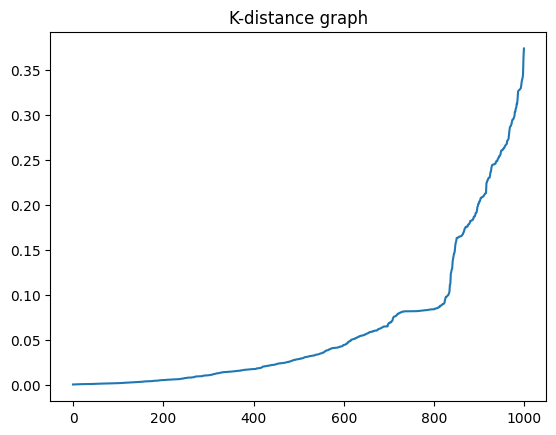

In [46]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("K-distance graph")
plt.show()


Training for: ['Annual_Spending', 'Purchase_Frequency']


<>:82: SyntaxWarning: invalid escape sequence '\T'
<>:82: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_2762/2139727060.py:82: SyntaxWarning: invalid escape sequence '\T'
  print("\Training complete")


DBSCAN clusters found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


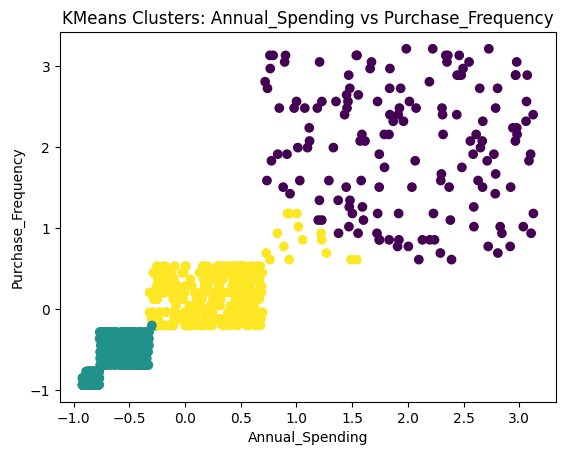

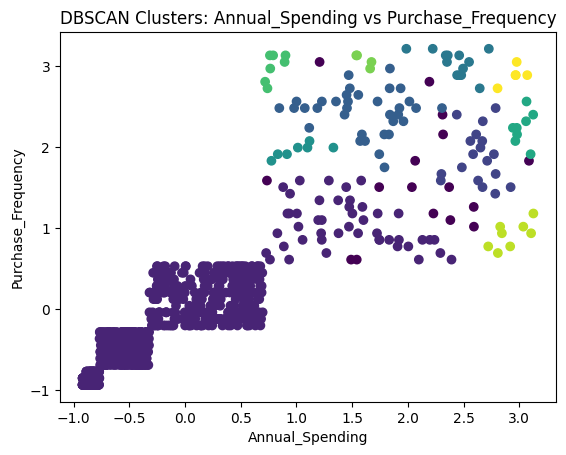

Saved artifacts for ['Annual_Spending', 'Purchase_Frequency']

Training for: ['Annual_Spending', 'Returns_Count']
DBSCAN clusters found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]


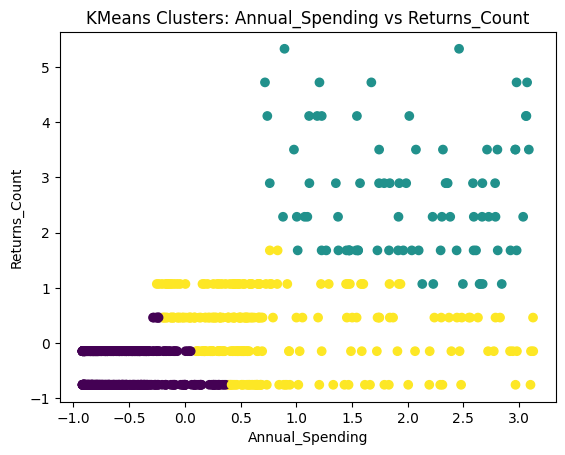

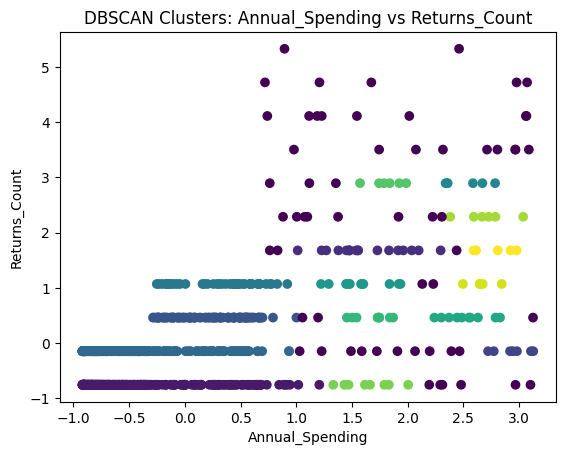

Saved artifacts for ['Annual_Spending', 'Returns_Count']

Training for: ['Purchase_Frequency', 'Discount_Usage_Pct']
DBSCAN clusters found: [np.int64(0), np.int64(1)]


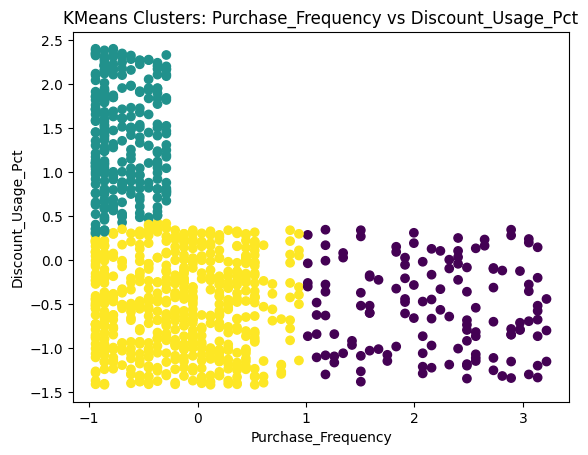

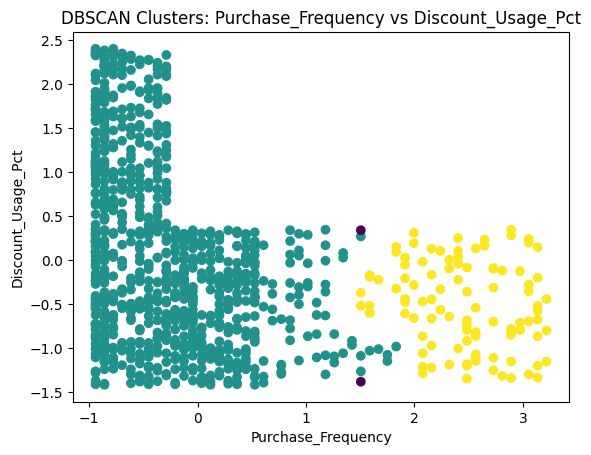

Saved artifacts for ['Purchase_Frequency', 'Discount_Usage_Pct']

Training for: ['Age', 'Annual_Spending']
DBSCAN clusters found: [np.int64(0), np.int64(1), np.int64(2)]


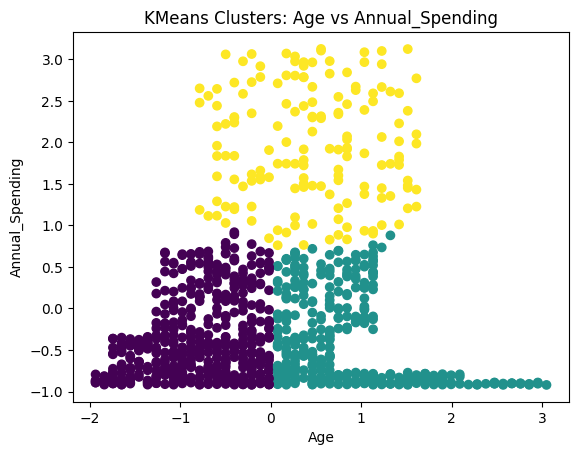

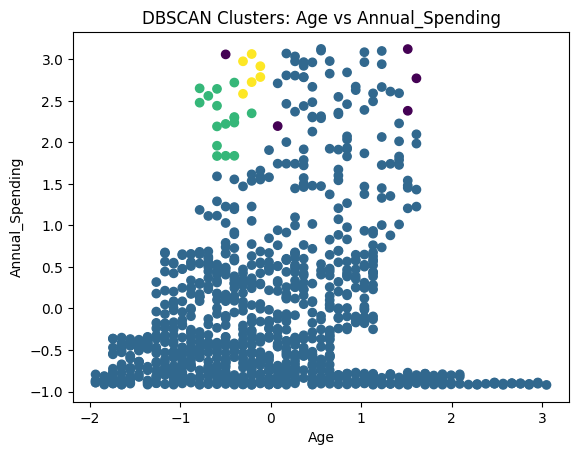

Saved artifacts for ['Age', 'Annual_Spending']

Training for: ['Age', 'Purchase_Frequency']
DBSCAN clusters found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


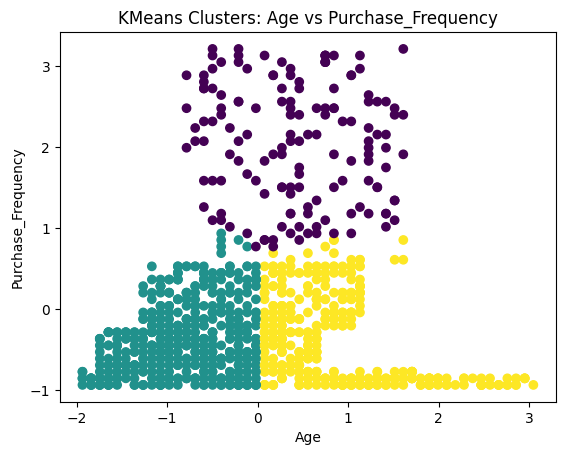

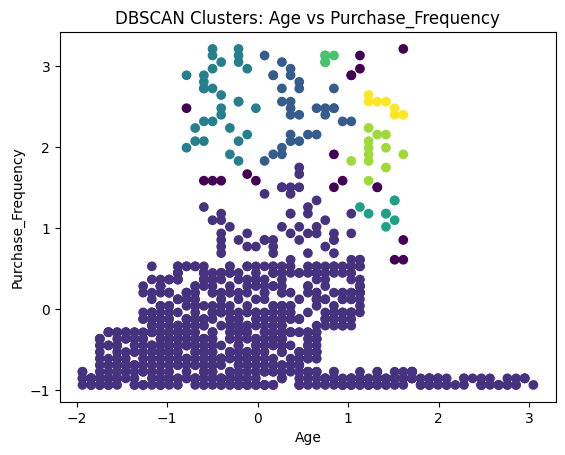

Saved artifacts for ['Age', 'Purchase_Frequency']
\Training complete


In [47]:

for features in feature_sets:
    print("\n==============================")
    print("Training for:", features)

    X = df[features].dropna().values

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ---------- KMEANS ----------
    kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
    kmeans.fit(X_scaled)

    # Create business labels
    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    order = np.argsort(centers[:, 0])  # rank by first feature
    kmeans_label_map = {
        order[0]: "Low Value Customer",
        order[1]: "Regular Customer",
        order[2]: "High Value Customer"
    }


    # ---------- DBSCAN ----------
    # Heuristic eps based on k-distance could be better; here we pick a reasonable default
    dbscan = DBSCAN(eps=0.25, min_samples=5)
    dbscan.fit(X_scaled)

    # DBSCAN labels: -1 = noise, others are cluster ids
    db_labels = dbscan.labels_

    # Computing centroids
    unique_clusters = [c for c in set(db_labels) if c != -1]
    db_centers = {}
    for c in unique_clusters:
        db_centers[c] = scaler.inverse_transform(X_scaled[db_labels == c]).mean(axis=0)

    # Sorting DBSCAN clusters by first feature
    if unique_clusters:
        sorted_db = sorted(unique_clusters, key=lambda c: db_centers[c][0])
        dbscan_label_map = {c: lbl for c, lbl in zip(sorted_db, [
            "Low Value Customer",
            "Regular Customer",
            "High Value Customer"
        ][:len(sorted_db)])}
    else:
        dbscan_label_map = {}

    print("DBSCAN clusters found:", unique_clusters)

    # ---------- VISUALIZing ----------
    plt.figure()
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_)
    plt.title(f"KMeans Clusters: {features[0]} vs {features[1]}")
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.show()

    plt.figure()
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels)
    plt.title(f"DBSCAN Clusters: {features[0]} vs {features[1]}")
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.show()

    # ---------- SAVE ARTIFACTS ----------
    key = "_".join(features)

    # KMeans
    pickle.dump(kmeans, open(f"{key}_kmeans_model.pkl", "wb"))
    pickle.dump(scaler, open(f"{key}_kmeans_scaler.pkl", "wb"))
    pickle.dump(kmeans_label_map, open(f"{key}_kmeans_labels.pkl", "wb"))

    # DBSCAN
    pickle.dump(dbscan, open(f"{key}_dbscan_model.pkl", "wb"))
    pickle.dump(scaler, open(f"{key}_dbscan_scaler.pkl", "wb"))
    pickle.dump(dbscan_label_map, open(f"{key}_dbscan_labels.pkl", "wb"))

    print(f"Saved artifacts for {features}")

print("\Training complete")

In [48]:
labels = dbscan.labels_

mask = labels != -1

if len(set(labels[mask])) > 1:
    sil_score = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette Score (DBSCAN):", sil_score)
else:
    print("Silhouette not valid (insufficient clusters)")

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

print("Clusters:", n_clusters)
print("Noise points:", noise)

Silhouette Score (DBSCAN): 0.32856725569510237
Clusters: 7
Noise points: 19


In [49]:
for features in feature_sets:
    X = df[features].dropna().values
    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)

    kmeans = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    print(f"Silhouette (KMeans) for {features}: {score:.3f}")

Silhouette (KMeans) for ['Annual_Spending', 'Purchase_Frequency']: 0.623
Silhouette (KMeans) for ['Annual_Spending', 'Returns_Count']: 0.519
Silhouette (KMeans) for ['Purchase_Frequency', 'Discount_Usage_Pct']: 0.520
Silhouette (KMeans) for ['Age', 'Annual_Spending']: 0.444
Silhouette (KMeans) for ['Age', 'Purchase_Frequency']: 0.452
